In [1]:
from os.path import exists
from pickle import dump, load

from animal_results import AnimalResults
from rate_calc import RateCalculator
from reference_tests import RefTests
from simulation_batch import Analyzer
from utilities import get_grid_figure

In [2]:
DUMP_FILE_NAME="dump/rates_vs_animals_per_group.pkl"
animal_results = AnimalResults.from_csv("LTP5_slope_diffsubjects.csv")
animals_per_group = list(range(5, 10)) + list(range(10, 22, 2))
analyzer = Analyzer(quiet=True)
reference_tests = RefTests(SAME_SUBJECTS=0, quiet=True)
rate_calculator = RateCalculator()
p_values_without_differences = []
p_values_with_differences = []
rates = []
if exists(DUMP_FILE_NAME):
    with open(DUMP_FILE_NAME, "rb") as file:
        rates = load(file)
else:
    for apg in animals_per_group:
        analyzer.analyze_data(
            animal_results=animal_results,
            ref_tests=reference_tests,
            iterations=25,
            animals_per_group=apg,
        )
        p_values_without_differences = analyzer.p_values
        analyzer.analyze_data(
            animal_results=animal_results,
            ref_tests=reference_tests,
            iterations=25,
            keep_differences=True,
            animals_per_group=apg,
        )
        p_values_with_differences = analyzer.p_values
        for i in range(len(p_values_without_differences[0])):
            rate_calculator.calculate_rates(p_values_without_differences[:, i], p_values_with_differences[:, i])
            if i >= len(rates):
                rates.append(
                    {
                        "fpr": {alpha: [] for alpha in rate_calculator.results},
                        "fnr": {alpha: [] for alpha in rate_calculator.results},
                    },
                )
            for alpha, readings in rate_calculator.results.items():
                rates[i]["fpr"][alpha].append(readings["FPR"])
                rates[i]["fnr"][alpha].append(readings["FNR"])
    with open(DUMP_FILE_NAME, "wb") as file:
        dump(rates, file)

/Users/patrickmichalik/PycharmProjects/InOutCurves/rate_calc.py:12: RuntimeWarning: invalid value encountered in scalar divide
  precision_diff = tpr_diff / (tpr_diff + fpr_no_diff)
/Users/patrickmichalik/PycharmProjects/InOutCurves/rate_calc.py:12: RuntimeWarning: invalid value encountered in scalar divide
  precision_diff = tpr_diff / (tpr_diff + fpr_no_diff)
/Users/patrickmichalik/PycharmProjects/InOutCurves/rate_calc.py:12: RuntimeWarning: invalid value encountered in scalar divide
  precision_diff = tpr_diff / (tpr_diff + fpr_no_diff)
/Users/patrickmichalik/PycharmProjects/InOutCurves/rate_calc.py:12: RuntimeWarning: invalid value encountered in scalar divide
  precision_diff = tpr_diff / (tpr_diff + fpr_no_diff)


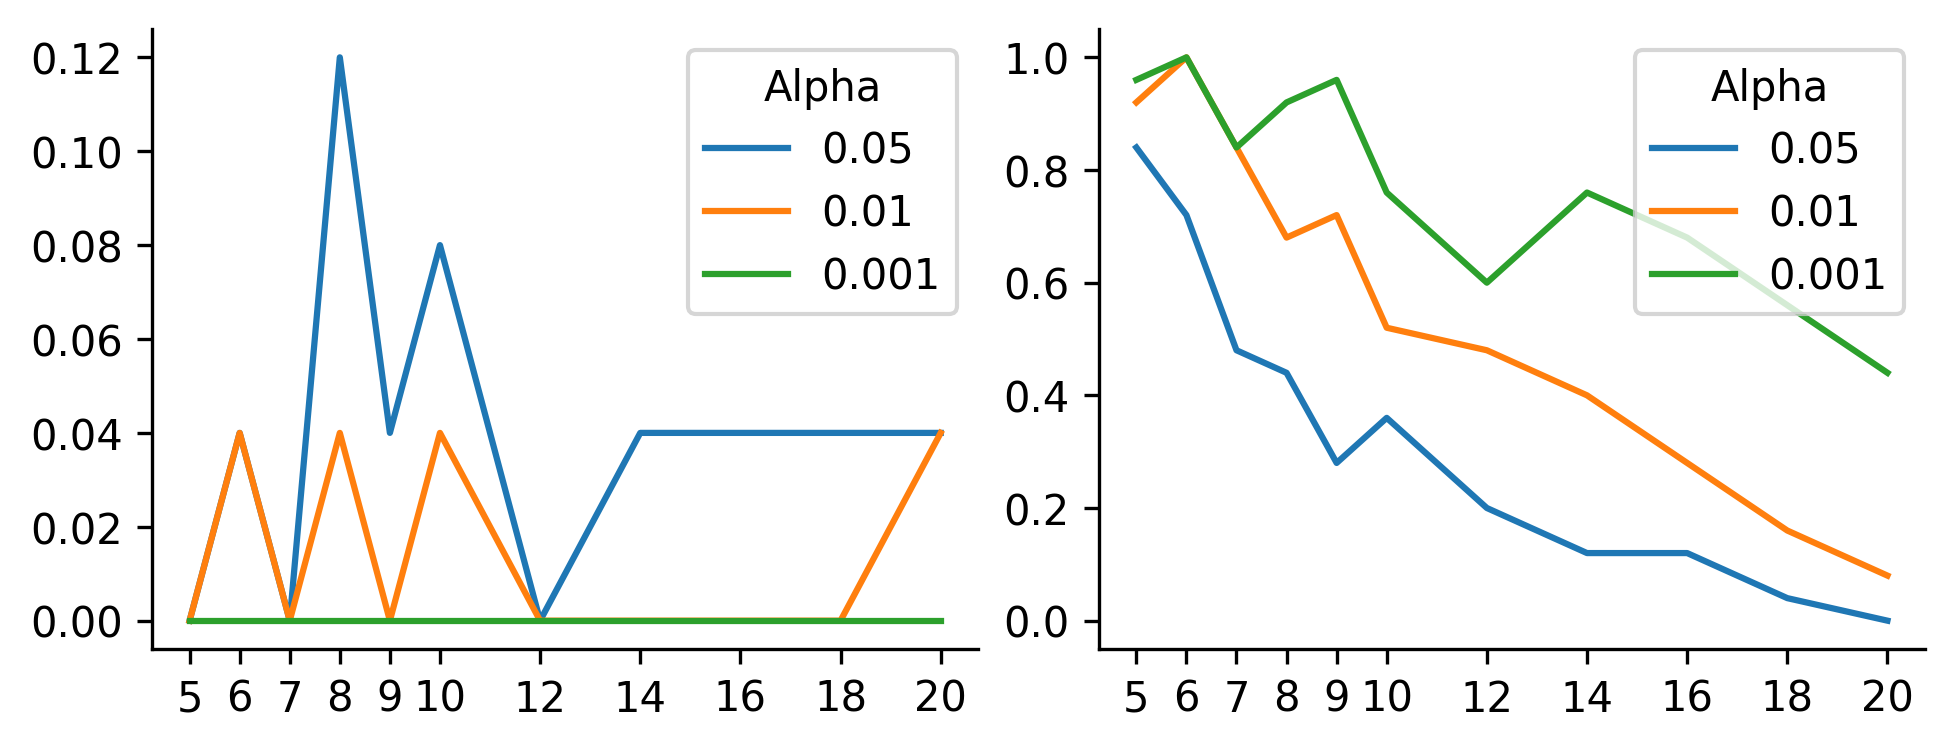

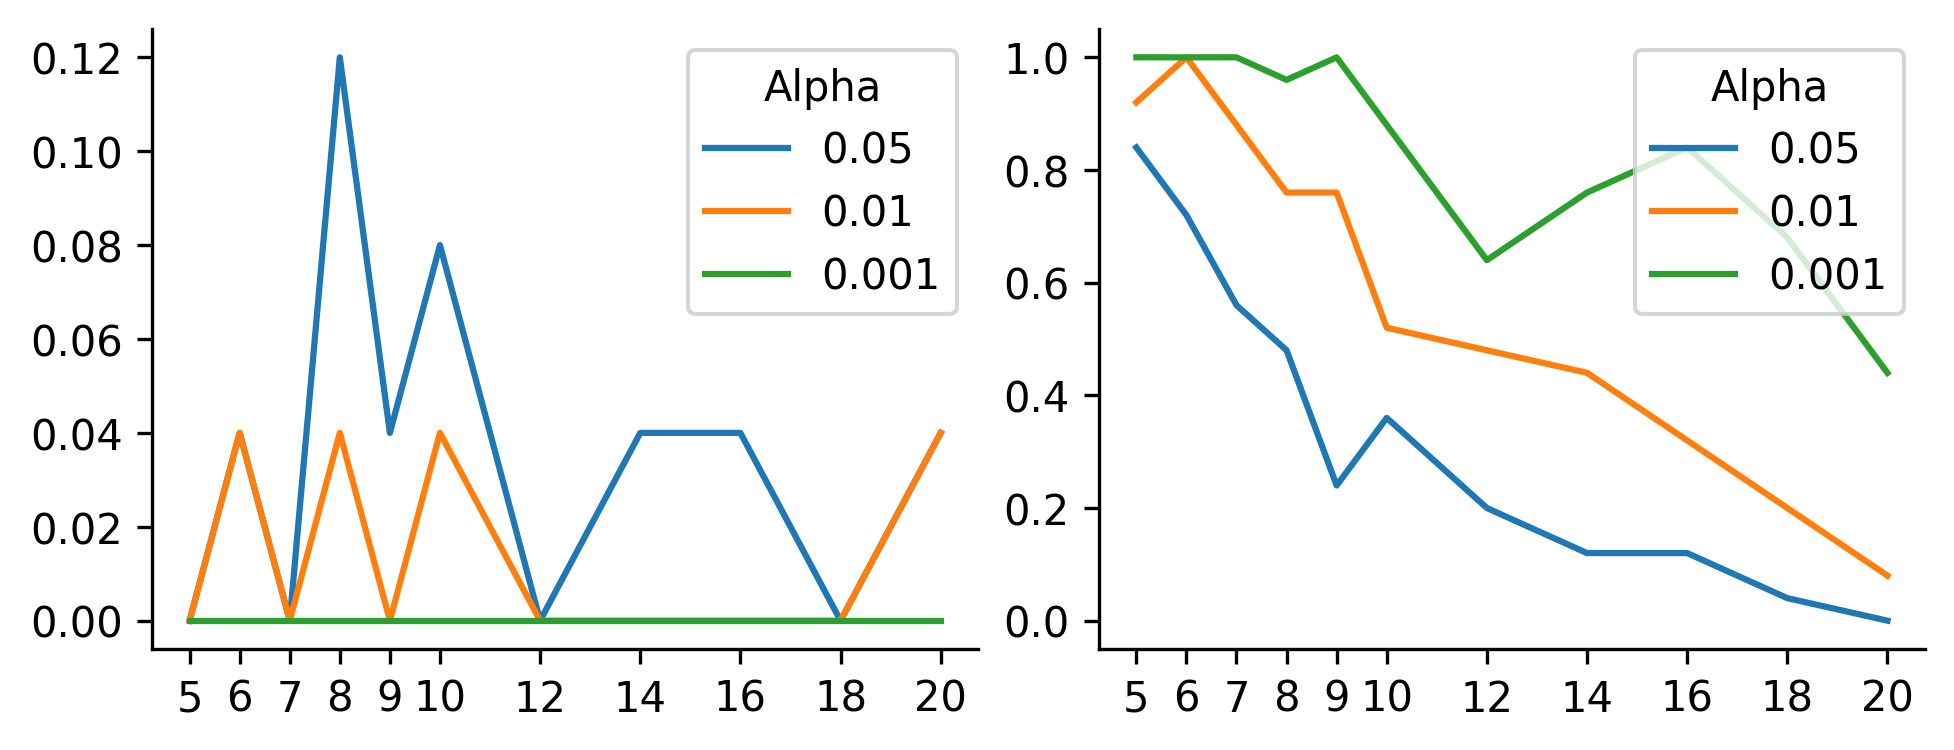

In [3]:
for r in rates:
    _, axes = get_grid_figure(column_count=len(r))
    for a in axes.flat:
        a.set_xticks(animals_per_group)
    for alpha, series in r["fpr"].items():
        axes[0].plot(animals_per_group, series, label=alpha)
        axes[0].legend(title="Alpha")
    for alpha, series in r["fnr"].items():
        axes[1].plot(animals_per_group, series, label=alpha)
        axes[1].legend(title="Alpha")